In [5]:
import pandas as pd
import os
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
import numpy as np
#Se importan modelos de aprendizaje y tambien el de comparación preentrenado (Textblob)
!pip install textblob
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
df_train = '/content/drive/My Drive/Colab Notebooks/TP3_DIPLO/Processed/train_topicos.csv'

In [35]:
df_train = pd.read_csv(df_train)

--- REPORTE FINAL: TEST SET ---
              precision    recall  f1-score   support

           0       0.84      0.72      0.77    160000
           2       0.00      0.00      0.00         0
           4       0.84      0.73      0.78    160000

    accuracy                           0.72    320000
   macro avg       0.56      0.48      0.52    320000
weighted avg       0.84      0.72      0.77    320000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


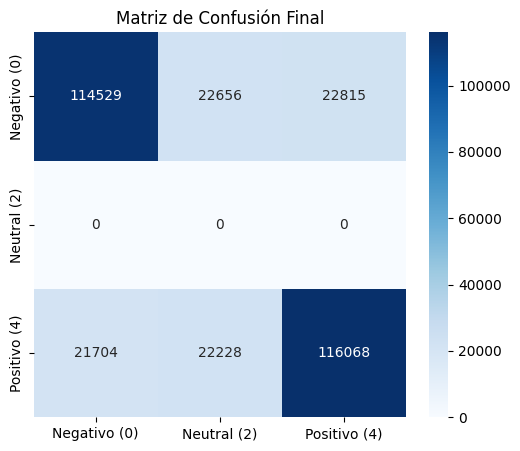

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 1. Cargar tus datos (asumiendo que df_train es tu único archivo fuente)
# Reemplaza con la ruta real de tu archivo
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/TP3_DIPLO/Processed/train_topicos.csv')
df['text_avanzado'] = df['text_avanzado'].fillna('')

# 2. Hacemos el split AHORA (antes de cualquier otra cosa)
# Esto garantiza que el TEST nunca se tocará durante el entrenamiento
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['target'])

# 3. Vectorización (Fit solo con el Train, Transform con ambos)
tfidf = TfidfVectorizer(max_features=None, ngram_range=(1,2))
X_train_vec = tfidf.fit_transform(df_train['text_avanzado'])
X_test_vec = tfidf.transform(df_test['text_avanzado'])

# 4. Entrenamiento
lr_model = LogisticRegression(solver='saga', n_jobs=-1, class_weight='balanced')
lr_model.fit(X_train_vec, df_train['target'])

nb_model = MultinomialNB()
nb_model.fit(X_train_vec, df_train['target'])

# 5. Función de umbral (para la lógica de clase 2)
def get_predictions_with_threshold(model, X_data, threshold=0.6):
    probs = model.predict_proba(X_data)
    max_probs = probs.max(axis=1)
    predictions = model.predict(X_data)
    return np.where(max_probs < threshold, 2, predictions)

# 6. Evaluación (Testeo final con el set que creamos nosotros)
threshold = 0.6
print("--- REPORTE FINAL: TEST SET ---")
preds_test = get_predictions_with_threshold(lr_model, X_test_vec, threshold)
print(classification_report(df_test['target'], preds_test))

# Matriz de confusión
cm = confusion_matrix(df_test['target'], preds_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo (0)', 'Neutral (2)', 'Positivo (4)'],
            yticklabels=['Negativo (0)', 'Neutral (2)', 'Positivo (4)'])
plt.title('Matriz de Confusión Final')
plt.show()


--- EVALUACIÓN: Regresión Logística ---

[TRAIN SET - Regresión Logística]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.91      0.75      0.82    640000
           2       0.00      0.00      0.00         0
           4       0.91      0.80      0.85    640000

    accuracy                           0.77   1280000
   macro avg       0.61      0.51      0.56   1280000
weighted avg       0.91      0.77      0.83   1280000


[TEST SET - Regresión Logística]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.84      0.72      0.77    160000
           2       0.00      0.00      0.00         0
           4       0.84      0.73      0.78    160000

    accuracy                           0.72    320000
   macro avg       0.56      0.48      0.52    320000
weighted avg       0.84      0.72      0.77    320000



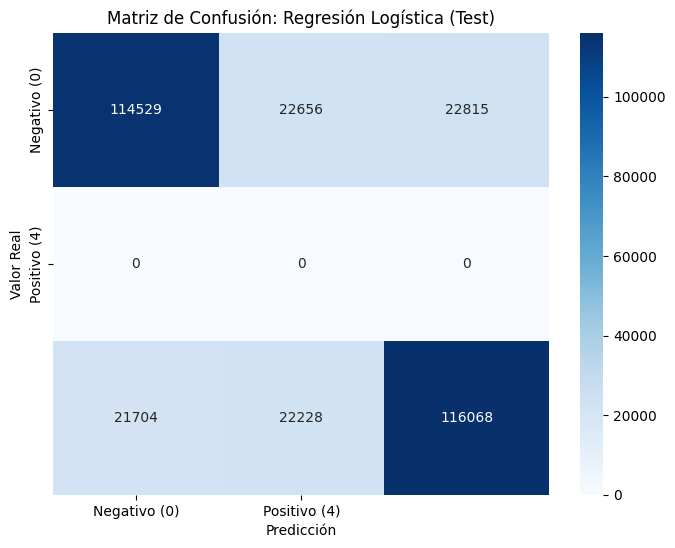


--- EVALUACIÓN: Naive Bayes ---

[TRAIN SET - Naive Bayes]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.94      0.83      0.88    640000
           2       0.00      0.00      0.00         0
           4       0.96      0.78      0.86    640000

    accuracy                           0.81   1280000
   macro avg       0.63      0.54      0.58   1280000
weighted avg       0.95      0.81      0.87   1280000


[TEST SET - Naive Bayes]
              precision    recall  f1-score   support

           0       0.84      0.68      0.75    160000
           2       0.00      0.00      0.00         0
           4       0.86      0.61      0.71    160000

    accuracy                           0.64    320000
   macro avg       0.57      0.43      0.49    320000
weighted avg       0.85      0.64      0.73    320000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


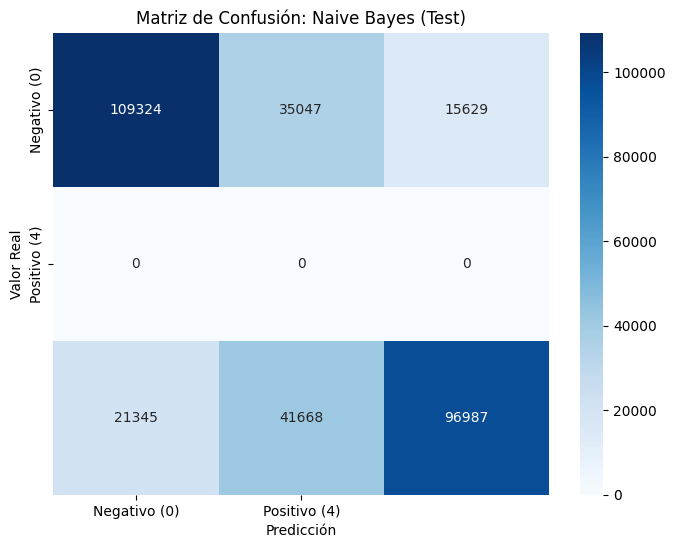

In [41]:
# 5. Evaluación de Modelos (Bucle corregido)
models = {'Regresión Logística': lr_model, 'Naive Bayes': nb_model}
threshold = 0.6

for name, model in models.items():
    print(f"\n--- EVALUACIÓN: {name} ---")

    # Evaluar Train
    preds_train = get_predictions_with_threshold(model, X_train_vec, threshold)
    print(f"\n[TRAIN SET - {name}]")
    print(classification_report(df_train['target'], preds_train))

    # Evaluar Test
    preds_test = get_predictions_with_threshold(model, X_test_vec, threshold)
    print(f"\n[TEST SET - {name}]")
    print(classification_report(df_test['target'], preds_test))

    # Mover la llamada aquí adentro para que se genere una matriz por cada modelo
    plot_confusion_matrix(df_test['target'], preds_test, f'Matriz de Confusión: {name} (Test)')

In [43]:
import joblib

# 1. Definimos la carpeta de destino en tu Drive
# Ajusta esta ruta si prefieres otra carpeta
export_path = '/content/drive/My Drive/Colab Notebooks/TP3_DIPLO/Models/'

joblib.dump(tfidf, export_path + 'tfidf_vectorizer.joblib')
joblib.dump(lr_model, export_path + 'lr_model.joblib')
joblib.dump(nb_model, export_path + 'nb_model.joblib')

print(f"Modelos y vectorizador guardados exitosamente en: {export_path}")

Modelos y vectorizador guardados exitosamente en: /content/drive/My Drive/Colab Notebooks/TP3_DIPLO/Models/
